# Cross match galaxies between NSA v101 and SGA 2025/2020

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits

from tqdm import tqdm

from astropy.coordinates import SkyCoord
from astropy.coordinates import match_coordinates_sky
from astropy import units as u

## read in SGA and NSA

In [6]:
NSA_fn = '/global/cfs/projectdirs/sdss/data/sdss/dr17/sdss/atlas/v1/nsa_v1_0_1.fits'
NSA = Table.read(NSA_fn)
NSA[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6833158000.0,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0
J094630.85-004554.5,09h/m00/J094630.85-004554.5,146.6285851269414,-0.7651620976591762,1,-1,-1,-1,-1,-1,17.318521,0.06465632,sdss,0.06491773,1239,2,175,301,735.56384,1277.3636,1,0.06403577,2.4606192 .. 443.66675,5.447516 .. 0.006137319,1,2.6590455 .. 454.05856,-14.978118 .. -20.68

In [7]:
SGA_2025_fn = '/global/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/SGA2025-beta-parent-refcat-v1.6.kd.fits'
SGA_2025 = Table.read(SGA_2025_fn)
SGA_2025[:5]

ra,dec,ref_id,mag,fitmode,pa,ba,diam
float64,float64,int64,float32,int32,float32,float32,float32
219.9258023922458,-32.53004546468686,4176048,17.78,0,70.35528,0.5832305,0.55550754
219.89199876009113,-32.34299358156585,4176016,17.71,0,150.42897,0.4607132,0.50789976
219.9409044773007,-32.331297660068095,242036,17.84,0,134.88263,0.22073081,0.68223655
220.20921498175156,-32.0109310161516,243654,18.04,0,91.79849,0.7038806,0.507167
220.3623232697446,-31.994910572523846,4257822,15.4,0,10.682078,0.6169077,1.0668384


In [8]:
SGA_2020_fn = '/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits'
SGA_2020 = Table.read(SGA_2020_fn, hdu='ELLIPSE')
SGA_2020[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

## make coords list for all

In [9]:
NSA_coords = SkyCoord(ra=NSA['RA']*u.degree, dec=NSA['DEC']*u.degree)
SGA_2020_coords = SkyCoord(ra=SGA_2020['RA']*u.degree, dec=SGA_2020['DEC']*u.degree)
SGA_2025_coords = SkyCoord(ra=SGA_2025['ra']*u.degree, dec=SGA_2025['dec']*u.degree)

## match NSA to SGA 2020

In [10]:
idx, d2d, d3d = NSA_coords.match_to_catalog_sky(SGA_2020_coords)

(array([8.5064e+04, 5.1480e+04, 1.7701e+04, 9.0160e+03, 5.2380e+03,
        3.3890e+03, 2.3110e+03, 1.6540e+03, 1.2280e+03, 1.0030e+03,
        7.9000e+02, 7.6400e+02, 6.7400e+02, 6.6800e+02, 6.6400e+02,
        6.9900e+02, 6.7400e+02, 6.0700e+02, 5.6200e+02, 5.2600e+02,
        5.2900e+02, 4.2200e+02, 3.8800e+02, 3.1000e+02, 3.1600e+02,
        2.6400e+02, 2.5500e+02, 2.3900e+02, 2.1900e+02, 1.8800e+02,
        1.9400e+02, 1.4800e+02, 1.5200e+02, 1.4500e+02, 1.1700e+02,
        1.3000e+02, 1.1100e+02, 1.0600e+02, 1.0900e+02, 9.6000e+01,
        9.4000e+01, 9.9000e+01, 8.2000e+01, 8.0000e+01, 9.0000e+01,
        7.0000e+01, 7.1000e+01, 7.1000e+01, 6.4000e+01, 5.2000e+01,
        5.6000e+01, 5.6000e+01, 4.9000e+01, 3.4000e+01, 3.9000e+01,
        4.0000e+01, 3.8000e+01, 4.5000e+01, 2.7000e+01, 3.6000e+01,
        2.7000e+01, 3.6000e+01, 3.6000e+01, 2.5000e+01, 2.5000e+01,
        2.5000e+01, 2.7000e+01, 2.1000e+01, 2.5000e+01, 1.7000e+01,
        1.5000e+01, 1.5000e+01, 2.1000e+01, 2.60

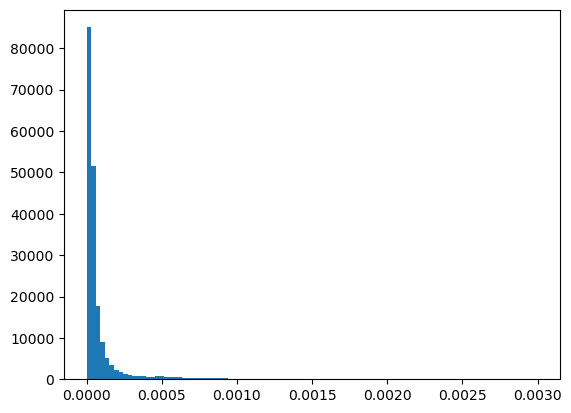

In [11]:
plt.hist(d2d, bins=np.linspace(0,0.003,100)*u.degree)

### make same cut as MaNGA sep < 0.00215

In [13]:
good_matches = d2d < 0.00215*u.degree

In [15]:
matched_nsa = NSA[good_matches]
matched_idx = idx[good_matches]

In [25]:
SGA_2020[matched_idx[0]]['SGA_ID']

393743

In [29]:
# idx is the index in SGA 2020 that corresponds to an NSA galaxy
matched_sga_id = np.ones(len(matched_nsa), dtype='int')*-999

for i in tqdm(range(len(matched_idx))):
    
    matched_sga_id[i] = SGA_2020[matched_idx[i]]['SGA_ID']

100%|██████████| 190622/190622 [00:00<00:00, 532316.86it/s]


In [30]:
matched_nsa['SGA_ID'] = matched_sga_id

In [35]:
matched_nsa['NSAID', 'SGA_ID'].write('/pscratch/sd/n/nravi/SGA2020_NSAv101_crossmatch_05182025_0p000215deg.txt',
                                     format='ascii.commented_header')

## match SGA 2025

In [36]:
idx, d2d, d3d = NSA_coords.match_to_catalog_sky(SGA_2025_coords)
good_matches = d2d < 0.00215*u.degree

In [37]:
matched_nsa = NSA[good_matches]
matched_idx = idx[good_matches]

In [39]:
SGA_2025[:5]

ra,dec,ref_id,mag,fitmode,pa,ba,diam
float64,float64,int64,float32,int32,float32,float32,float32
219.9258023922458,-32.53004546468686,4176048,17.78,0,70.35528,0.5832305,0.55550754
219.89199876009113,-32.34299358156585,4176016,17.71,0,150.42897,0.4607132,0.50789976
219.9409044773007,-32.331297660068095,242036,17.84,0,134.88263,0.22073081,0.68223655
220.20921498175156,-32.0109310161516,243654,18.04,0,91.79849,0.7038806,0.507167
220.3623232697446,-31.994910572523846,4257822,15.4,0,10.682078,0.6169077,1.0668384


In [40]:
# idx is the index in SGA 2020 that corresponds to an NSA galaxy
matched_sga_id = np.ones(len(matched_nsa), dtype='int')*-999

for i in tqdm(range(len(matched_idx))):
    
    matched_sga_id[i] = SGA_2025[matched_idx[i]]['ref_id']

100%|██████████| 154273/154273 [00:00<00:00, 553505.50it/s]


In [41]:
matched_nsa['SGA_2025_ref_id'] = matched_sga_id
matched_nsa['SGA_2025_idx'] = matched_idx

In [43]:
matched_nsa['NSAID', 'SGA_2025_idx', 'SGA_2025_ref_id'].write('/pscratch/sd/n/nravi/SGA2025_NSAv101_crossmatch_05182025_0p000215deg.txt',
                                     format='ascii.commented_header')